In [90]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
#from sklearn.preprocessing import StandardScaler
import numpy as np
from astropy.io import fits
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.cluster import HDBSCAN
import astropy.units as u
# from zero_point import zpt
from tqdm import tqdm
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from astropy.table import Table

In [ ]:
#Primera parte: Análisis de M41
#Leemos el csv 
fits_file = 'M41_pm_3.fits'
fits.info(fits_file)
fits.getheader(fits_file, ext=1)

Filename: M41_pm_3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1                1 BinTableHDU    157   2000R x 33C   [28A, K, D, D, D, D, D, E, E, E, E, E, E, 13A, I, L, L, L, L, L, L, L, E, E, E, E, E, E, E, 8A, D, D, D]   


XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional table                            
NAXIS1  =                  182 / width of table in bytes                        
NAXIS2  =                 2000 / number of rows in table                        
PCOUNT  =                    0 / heap size (no gap)                             
GCOUNT  =                    1 / one data group                                 
TFIELDS =                   33 / number of columns                              
TTYPE1  = 'designation'        / label for column 1                             
TFORM1  = '28A     '           / format for column 1                            
TCOMM1  = 'Unique source designation (unique across all Data Releases)'         
TUCD1   = 'meta.id;meta.main'  / VO Unified Content Descriptor for column 1     
TTYPE2  = 'source_id'       

In [97]:
#Convertimos el archivo fits a un dataframe de pandas
with fits.open(fits_file) as hdul:
    data = hdul[1].data
tabla = Table(data)
print(tabla[:5])
df = tabla.to_pandas()
print(df.head())

        designation               source_id      ... target_separation (deg)
---------------------------- ------------------- ... -----------------------
Gaia DR3 2927008980895404928 2927008980895404928 ...    0.009720672614521595
Gaia DR3 2927008980895405056 2927008980895405056 ...    0.011217890065282055
Gaia DR3 2927008980895402368 2927008980895402368 ...    0.012853041521138696
Gaia DR3 2927008224981157760 2927008224981157760 ...     0.01581567692825537
Gaia DR3 2927008980887462400 2927008980887462400 ...    0.017236907327403378
                    designation            source_id          ra        dec  \
0  Gaia DR3 2927008980895404928  2927008980895404928  101.502278 -20.744786   
1  Gaia DR3 2927008980895405056  2927008980895405056  101.498937 -20.743019   
2  Gaia DR3 2927008980895402368  2927008980895402368  101.502818 -20.741685   
3  Gaia DR3 2927008224981157760  2927008224981157760  101.516279 -20.750904   
4  Gaia DR3 2927008980887462400  2927008980887462400  101.510297 -

In [173]:
#Elegimos las columnas que vamos a usar para el clustering
clustering_on = ['pmra', 'pmdec', 'parallax']
data = df[clustering_on]
data = RobustScaler().fit_transform(data) #Escalamos los datos para que tengan media 0 y desviación estándar 1

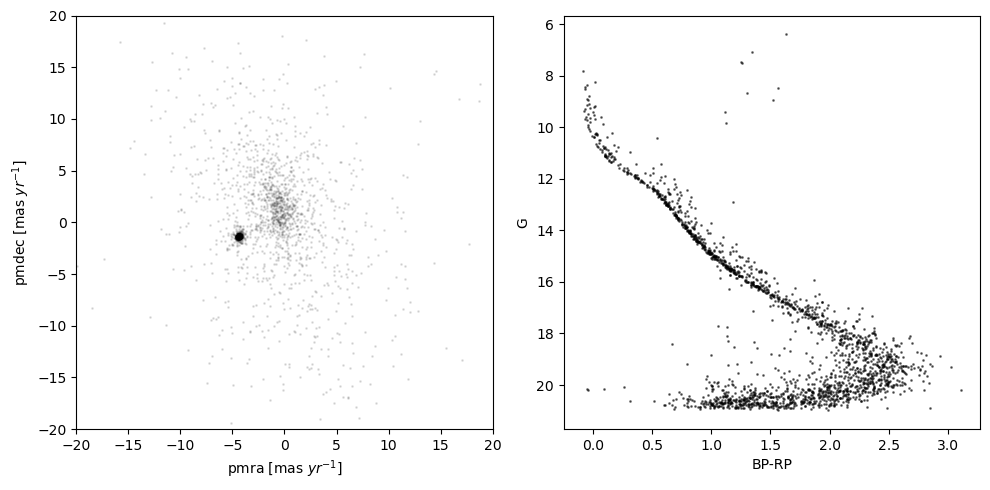

In [274]:
#Graficamos Diagrama Vectorial de Puntos y Diagrama Magnitud-Color
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].scatter(df['pmra'], df['pmdec'], s=1, alpha=0.1, c='k')
ax[0].set_xlabel("pmra [mas $yr^{-1}$]")
ax[0].set_ylabel("pmdec [mas $yr^{-1}$]")
ax[0].set_ylim(-20, 20)
ax[0].set_xlim(-20, 20)

ax[1].scatter(df['bp_rp'], df['phot_g_mean_mag'], s=1, alpha=0.5, c='k')
ax[1].set_xlabel("BP-RP")
ax[1].set_ylabel("G")
ax[1].invert_yaxis()
fig.tight_layout()

In [275]:
#Aplicamos HDBSCAN para encontrar los clusters
#Sabemos que un cúmulo abierto tiene mínimo 100 estrellas, elegimos min_cluster_size=100
#Usamos min_samples=6 partiendo de que hay 3 dimensiones

hd = HDBSCAN(min_cluster_size=100, min_samples=6, metric='euclidean').fit(data)

In [276]:
labels = hd.labels_ 
df['label_hb'] = labels
for i in list(set(labels)):
    print('{} {}'.format(i,len(df[(df['label_hb'] == i)])))

0 579
1 374
-1 1047


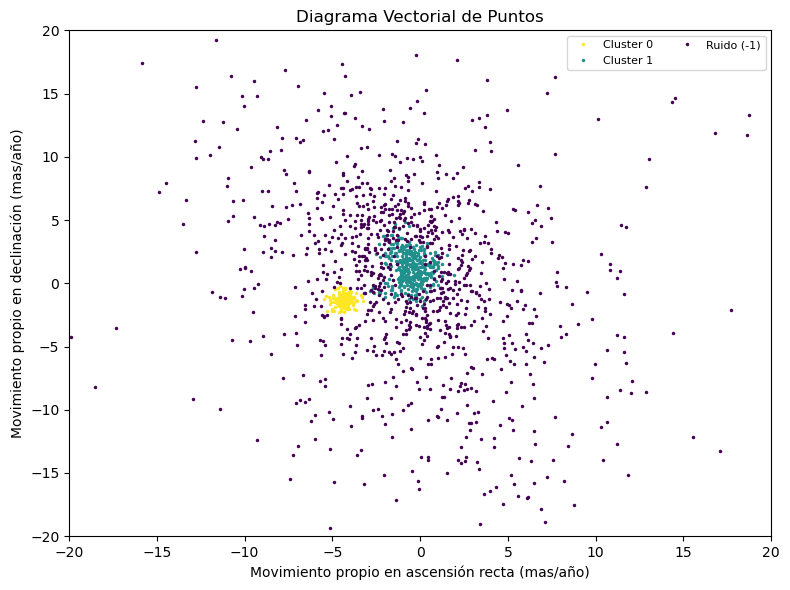

In [308]:
unique_labels = set(labels)
colors = plt.cm.viridis_r(np.linspace(0, 1, len(unique_labels)))
plt.figure(figsize=(8,6))
for i, j in zip(list(unique_labels), colors):
    #if i != -1:
        condition = (df['label_hb'] == i)
        legend_label = 'Ruido (-1)' if i == -1 else f'Cluster {i}'
        plt.plot(df['pmra'][condition], df['pmdec'][condition], 
         markerfacecolor = tuple(j), markeredgewidth=0, marker = 'o', linestyle='None',markersize = 2.5, alpha = 1,
         label=legend_label)
plt.ylim(-20, 20)
plt.xlim(-20, 20)
plt.title('Diagrama Vectorial de Puntos')
plt.xlabel('Movimiento propio en ascensión recta (mas/año)')

plt.ylabel('Movimiento propio en declinación (mas/año)')
plt.legend()
plt.legend(loc='best', fontsize=8, ncol=2, frameon=True)
plt.tight_layout()
plt.savefig('M41_vectorial.png', dpi=300)
plt.show()

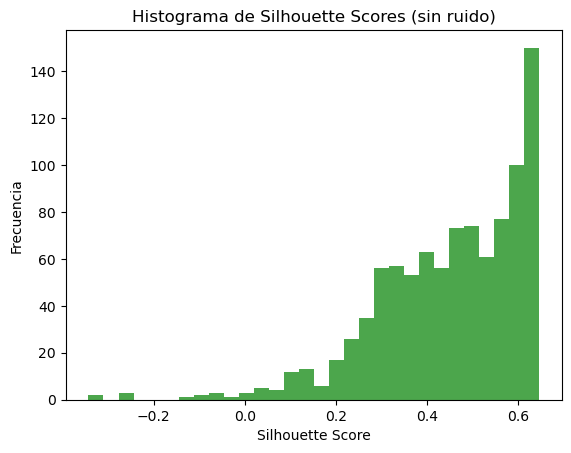

In [278]:
# Calcular silhouette score sin ruido (label = -1)
mask = labels != -1
labels_clean = labels[mask]
data_clean = data[mask]

score = silhouette_score(data_clean, labels_clean)

values = silhouette_samples(data_clean, labels_clean)

plt.hist(values, bins=30, color='g', alpha=0.7)
plt.title('Histograma de Silhouette Scores (sin ruido)')
plt.xlabel('Silhouette Score')
plt.ylabel('Frecuencia')
plt.show()

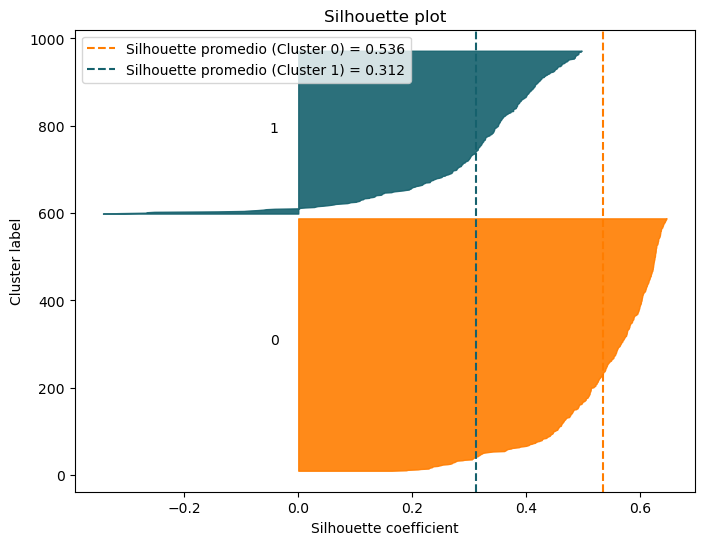

In [307]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples

# Calcular silhouette por punto
values = silhouette_samples(data, labels)

# promedio por separado para labels 0 y 1
score_0 = np.mean(values[labels == 0]) if np.any(labels == 0) else None
score_1 = np.mean(values[labels == 1]) if np.any(labels == 1) else None


unique_labels = np.unique(labels)
n_clusters = len(unique_labels)

y_lower = 10
silhouette_colors = ['#ff7d00', '#15616d']
color_idx = 0

plt.figure(figsize=(8,6))

for i in unique_labels:
    if i == -1:
        continue
    cluster_values = values[labels == i]
    cluster_values.sort()

    size_cluster = cluster_values.shape[0]
    y_upper = y_lower + size_cluster

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values,
        color=silhouette_colors[color_idx % len(silhouette_colors)],
        alpha=0.9
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(i))

    y_lower = y_upper + 10
    color_idx += 1

# líneas de silhouette promedio para 0 y 1 por separado
if score_0 is not None:
    plt.axvline(
        x=score_0,
        linestyle="--",
        label="Silhouette promedio (Cluster 0) = " + str(score_0.round(3)),
        color="#ff7d00"
    )

if score_1 is not None:
    plt.axvline(
        x=score_1,
        linestyle="--",
        label="Silhouette promedio (Cluster 1) = " + str(score_1.round(3)),
        color="#15616d"
    )

plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster label")
plt.legend()
plt.title("Silhouette plot")
plt.savefig('silhouette_m41.png', dpi=300)

plt.show()

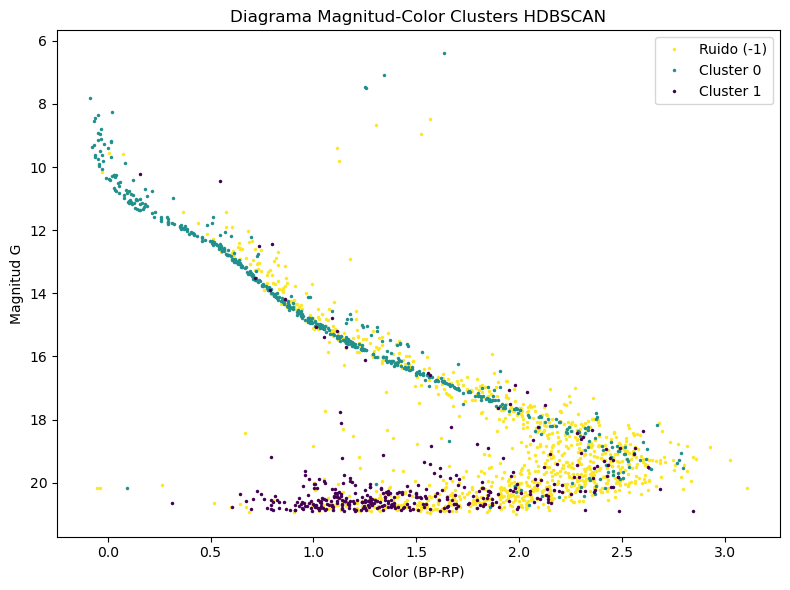

In [306]:
#Graficamos Diagrama Magnitud-Color con los clusters encontrados
plt.figure(figsize=(8,6))
for i, j in zip(list(unique_labels), colors):
    condition = (df['label_hb'] == i)
    legend_label = 'Ruido (-1)' if i == -1 else f'Cluster {i}'
    plt.plot(df['bp_rp'][condition], df['phot_g_mean_mag'][condition], 
     markerfacecolor = tuple(j), markeredgewidth=0, marker = 'o', linestyle='None',markersize = 2.5, alpha = 1,
     label=legend_label)
plt.xlabel("Color (BP-RP)")
plt.ylabel("Magnitud G")
plt.title('Diagrama Magnitud-Color Clusters HDBSCAN')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.savefig('M41_HDBSCAN.png', dpi=300)
plt.show() 

Número de estrellas en el cluster encontrado por ML:  579
Número de estrellas en el cluster encontrado por el método tradicional:  532
47


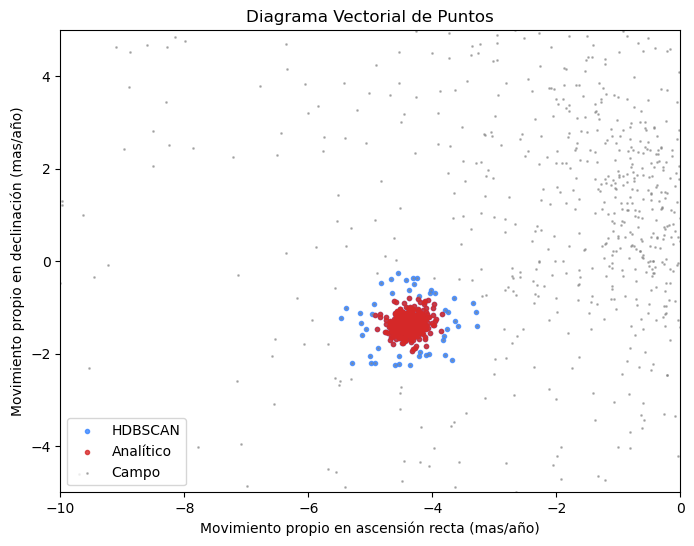

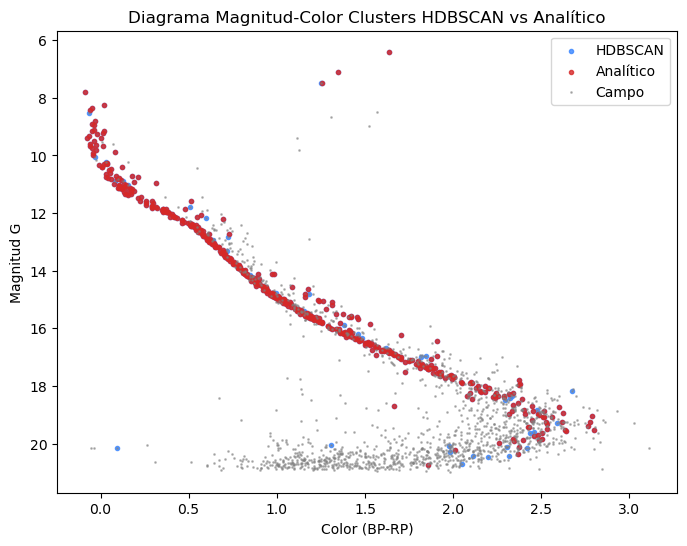

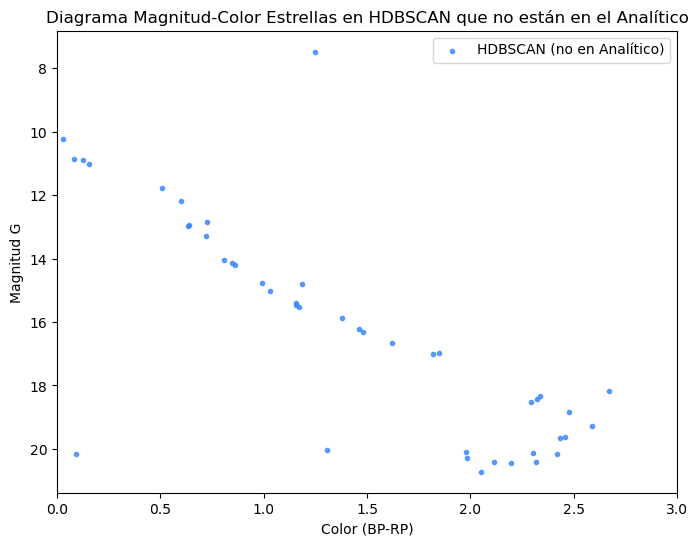

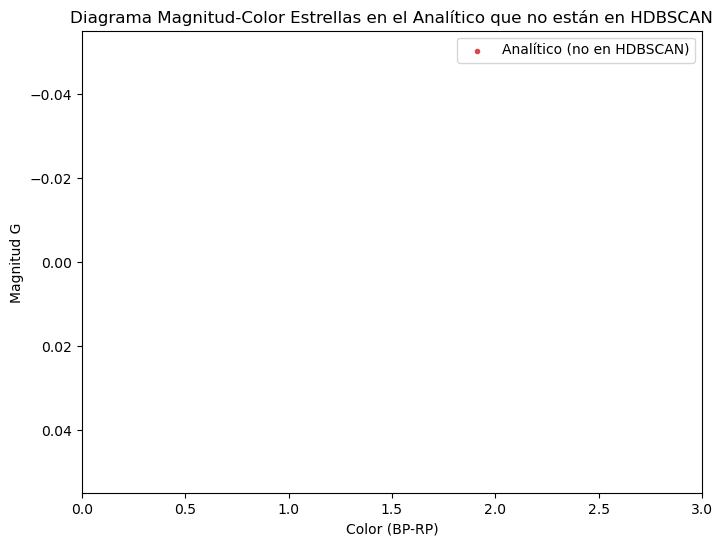

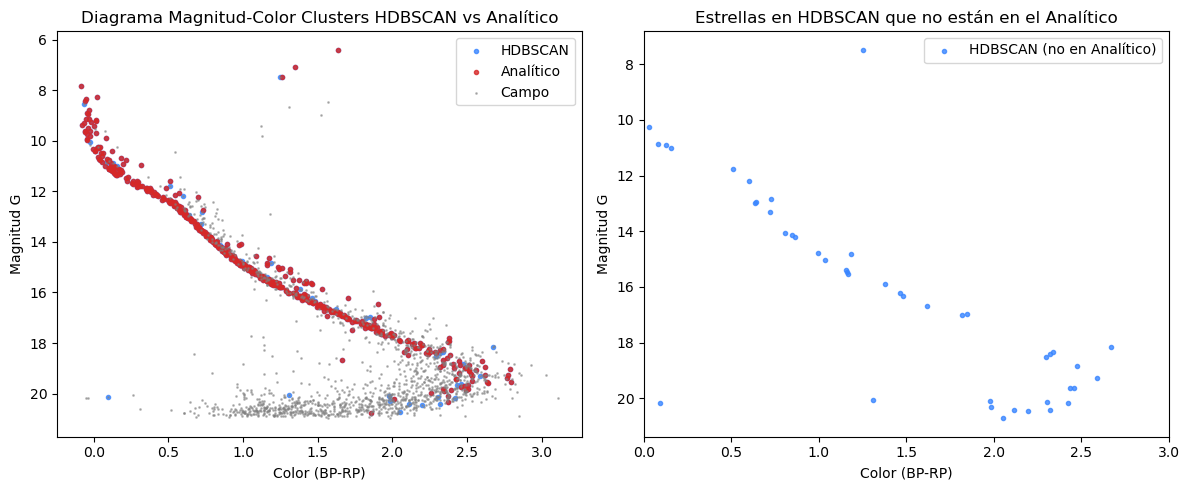

In [296]:
#Identificamos al Cluster 0 como M41
cluster_ML=df[df['label_hb'] == 0]
#Comparamos con el cluster encontrado por el método tradicional
cluster_analitico = pd.read_csv('miembros_cumulo.csv')
campo = pd.read_csv('estrellas_campo.csv')
print("Número de estrellas en el cluster encontrado por ML: ", len(cluster_ML))
print("Número de estrellas en el cluster encontrado por el método tradicional: ", len(cluster_analitico))
#Diagrama Vectorial de Puntos con los clusters encontrados por ML y Analitico
plt.figure(figsize=(8,6))
plt.scatter(cluster_ML['pmra'], cluster_ML['pmdec'], c='#3a86ff', s=9, alpha=0.8, label='HDBSCAN')
plt.scatter(cluster_analitico['pmra'], cluster_analitico['pmdec'], c='#d62828', s=9, alpha=0.8, label='Analítico')
plt.scatter(campo['pmra'], campo['pmdec'], c='gray', s=1, alpha=0.5, label='Campo')
plt.ylim(-5, 5)
plt.xlim(-10, 0)
plt.title('Diagrama Vectorial de Puntos')
plt.xlabel('Movimiento propio en ascensión recta (mas/año)')
plt.ylabel('Movimiento propio en declinación (mas/año)')
plt.legend()
#Diagrama Magnitud-Color con los clusters encontrados por ML y Analitico
plt.figure(figsize=(8,6))
plt.scatter(cluster_ML['bp_rp'], cluster_ML['phot_g_mean_mag'], c='#3a86ff', s=9, alpha=0.8, label='HDBSCAN')
plt.scatter(cluster_analitico['color'], cluster_analitico['g_mag'], c='#d62828', s=9, alpha=0.8, label='Analítico')
plt.scatter(campo['color'], campo['g_mag'], c='gray', s=1, alpha=0.5, label='Campo')
plt.xlabel("Color (BP-RP)")
plt.ylabel("Magnitud G")
plt.gca().invert_yaxis()
plt.title('Diagrama Magnitud-Color Clusters HDBSCAN vs Analítico')
plt.legend()
#Diagrama Magnitud-Color estrellas en ML que no están en el analítico
estrellas_no_analitico = cluster_ML[~cluster_ML['source_id'].isin(cluster_analitico['source_id'])]
print(len(estrellas_no_analitico))
plt.figure(figsize=(8,6))
plt.scatter(estrellas_no_analitico['bp_rp'], estrellas_no_analitico['phot_g_mean_mag'], c='#3a86ff', s=9, alpha=0.8, label='HDBSCAN (no en Analítico)')
plt.xlabel("Color (BP-RP)") 
plt.xlim(0,3)
plt.ylabel("Magnitud G")
plt.gca().invert_yaxis()
plt.title('Diagrama Magnitud-Color Estrellas en HDBSCAN que no están en el Analítico')
plt.legend()
plt.savefig('M41_comparacion_VPD.png', dpi=300)
#Diagrama Magnitud-Color estrellas en el analítico que no están en el ML
estrellas_no_ml = cluster_analitico[~cluster_analitico['source_id'].isin(cluster_ML['source_id'])]
plt.figure(figsize=(8,6))  
plt.scatter(estrellas_no_ml['color'], estrellas_no_ml['g_mag'], c='#d62828', s=9, alpha=0.8, label='Analítico (no en HDBSCAN)')
plt.xlabel("Color (BP-RP)")
plt.xlim(0,3)
plt.ylabel("Magnitud G")
plt.gca().invert_yaxis()
plt.title('Diagrama Magnitud-Color Estrellas en el Analítico que no están en HDBSCAN')
plt.legend()
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(cluster_ML['bp_rp'], cluster_ML['phot_g_mean_mag'], c='#3a86ff', s=9, alpha=0.8, label='HDBSCAN')
plt.scatter(cluster_analitico['color'], cluster_analitico['g_mag'], c='#d62828', s=9, alpha=0.8, label='Analítico')
plt.scatter(campo['color'], campo['g_mag'], c='gray', s=1, alpha=0.5, label='Campo')
plt.xlabel("Color (BP-RP)")
plt.ylabel("Magnitud G")
plt.gca().invert_yaxis()
plt.title('Diagrama Magnitud-Color Clusters HDBSCAN vs Analítico')
plt.legend()
plt.subplot(1,2,2)
plt.scatter(estrellas_no_analitico['bp_rp'], estrellas_no_analitico['phot_g_mean_mag'], c='#3a86ff', s=9, alpha=0.8, label='HDBSCAN (no en Analítico)')
plt.xlabel("Color (BP-RP)") 
plt.xlim(0,3)
plt.ylabel("Magnitud G")
plt.gca().invert_yaxis()
plt.title('Estrellas en HDBSCAN que no están en el Analítico')
plt.legend()
plt.tight_layout()
plt.savefig('M41_comparacion_CMD.png', dpi=300)


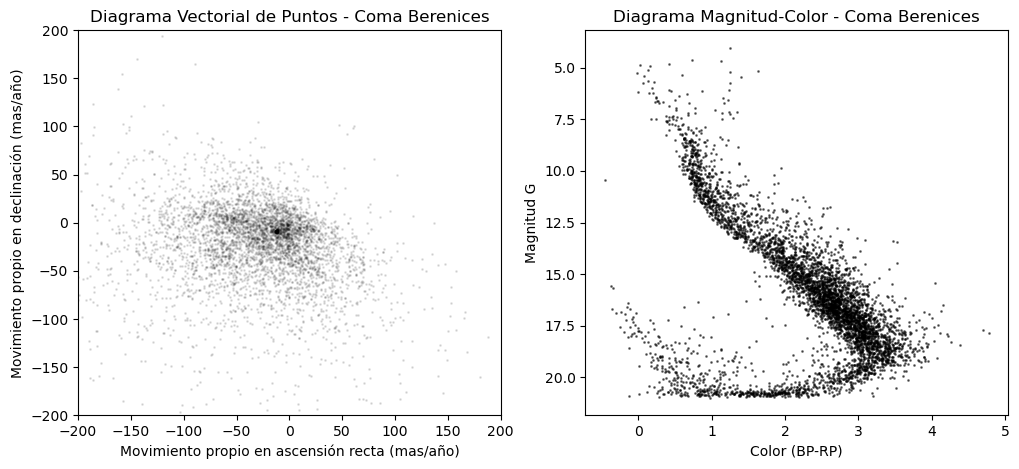

In [299]:
#Análisis de los datos de Coma Berenices
coma = pd.read_csv('Coma_Cluster_GAIA_DR3.csv')
#Diagrama Vectorial de Puntos y Diagrama Magnitud-Color
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(coma['pmra'], coma['pmdec'], s=1, alpha=0.1, c='k')
plt.xlabel('Movimiento propio en ascensión recta (mas/año)')
plt.ylabel('Movimiento propio en declinación (mas/año)')
plt.title('Diagrama Vectorial de Puntos - Coma Berenices')
plt.ylim(-200, 200)
plt.xlim(-200, 200)
plt.subplot(1,2,2)
plt.scatter(coma['bp_rp'], coma['phot_g_mean_mag'], s=1, alpha=0.5, c='k')
plt.xlabel('Color (BP-RP)')
plt.ylabel('Magnitud G')
plt.gca().invert_yaxis()
plt.title('Diagrama Magnitud-Color - Coma Berenices')
plt.savefig('coma_berenices_diagramas.png', dpi=300)

In [300]:
#Hacemos clustering con HDBSCAN para encontrar el cúmulo de Coma Berenices
data_coma = coma[['pmra', 'pmdec', 'parallax']]
data_coma = RobustScaler().fit_transform(data_coma)
hd_coma = HDBSCAN(min_cluster_size=100, min_samples=10, metric='euclidean').fit(data_coma)
labels_coma = hd_coma.labels_
coma['label_hb'] = labels_coma
for i in list(set(labels_coma)):
    print('{} {}'.format(i,len(coma[(coma['label_hb'] == i)])))


0 2981
1 155
-1 1874


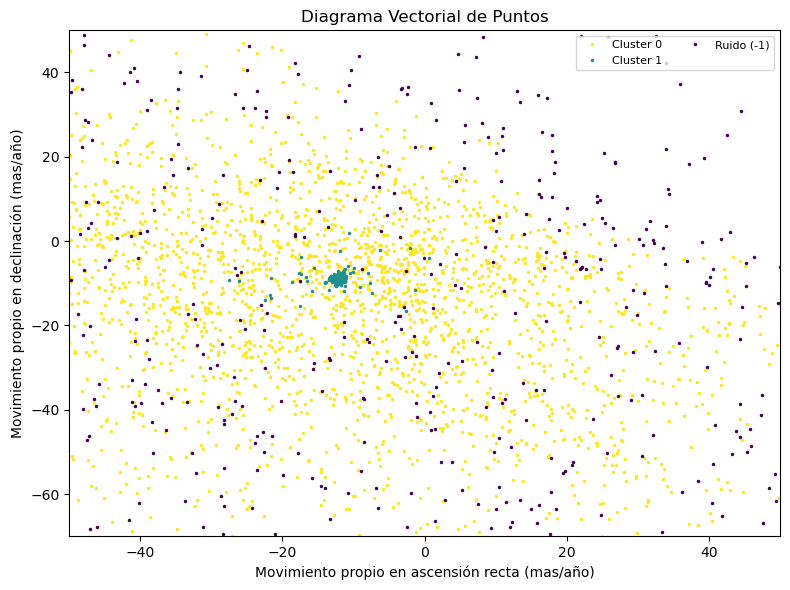

In [301]:
unique_labels_coma = set(labels_coma)
colors = plt.cm.viridis_r(np.linspace(0, 1, len(unique_labels_coma)))
plt.figure(figsize=(8,6))
for i, j in zip(list(unique_labels_coma), colors):
    #if i != -1:
        condition = (coma['label_hb'] == i)
        legend_label = 'Ruido (-1)' if i == -1 else f'Cluster {i}'
        plt.plot(coma['pmra'][condition], coma['pmdec'][condition], 
         markerfacecolor = tuple(j), markeredgewidth=0, marker = 'o', linestyle='None',markersize = 2.5, alpha = 1,
         label=legend_label)
plt.ylim(-70, 50)
plt.xlim(-50, 50)
plt.title('Diagrama Vectorial de Puntos')
plt.xlabel('Movimiento propio en ascensión recta (mas/año)')

plt.ylabel('Movimiento propio en declinación (mas/año)')
plt.legend()
plt.legend(loc='best', fontsize=8, ncol=2, frameon=True)
plt.tight_layout()
plt.savefig('coma_vectorial.png', dpi=300)
plt.show()

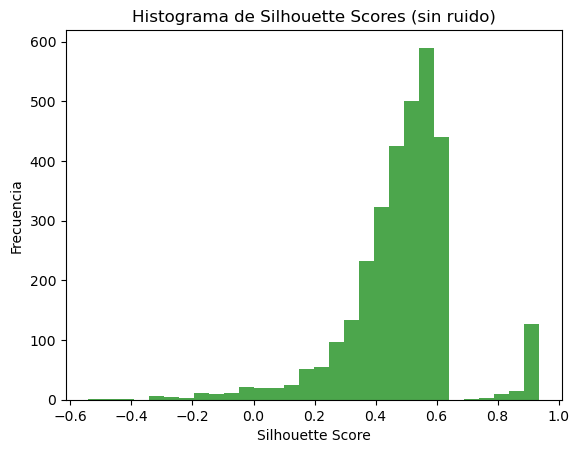

In [302]:
# Calcular silhouette score sin ruido (label = -1)
mask = labels_coma != -1
labels_clean = labels_coma[mask]
data_clean = data_coma[mask]

score = silhouette_score(data_clean, labels_clean)

values = silhouette_samples(data_clean, labels_clean)

plt.hist(values, bins=30, color='g', alpha=0.7)
plt.title('Histograma de Silhouette Scores (sin ruido)')
plt.xlabel('Silhouette Score')
plt.ylabel('Frecuencia')
plt.show()

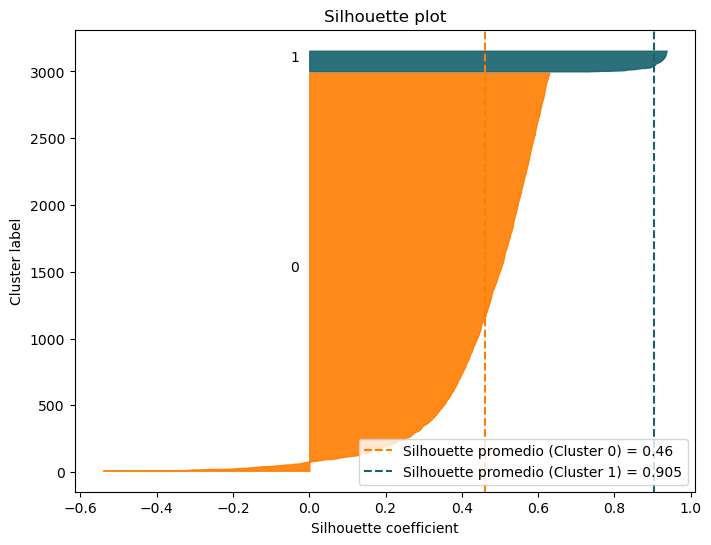

In [303]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples

# Calcular silhouette por punto
values_coma = silhouette_samples(data_coma, labels_coma)

# promedio por separado para labels 0 y 1
score_0 = np.mean(values_coma[labels_coma == 0]) if np.any(labels_coma == 0) else None
score_1 = np.mean(values_coma[labels_coma == 1]) if np.any(labels_coma == 1) else None


unique_labels = np.unique(labels_coma)
n_clusters = len(unique_labels)

y_lower = 10
silhouette_colors = ['#ff7d00', '#15616d']
color_idx = 0

plt.figure(figsize=(8,6))

for i in unique_labels:
    if i == -1:
        continue
    cluster_values = values_coma[labels_coma == i]
    cluster_values.sort()

    size_cluster = cluster_values.shape[0]
    y_upper = y_lower + size_cluster

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values,
        color=silhouette_colors[color_idx % len(silhouette_colors)],
        alpha=0.9
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(i))

    y_lower = y_upper + 10
    color_idx += 1

# líneas de silhouette promedio para 0 y 1 por separado
if score_0 is not None:
    plt.axvline(
        x=score_0,
        linestyle="--",
        label="Silhouette promedio (Cluster 0) = " + str(score_0.round(3)),
        color="#ff7d00"
    )

if score_1 is not None:
    plt.axvline(
        x=score_1,
        linestyle="--",
        label="Silhouette promedio (Cluster 1) = " + str(score_1.round(3)),
        color="#15616d"
    )

plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster label")
plt.legend()
plt.title("Silhouette plot")
plt.savefig('silhouette_coma.png', dpi=300)

plt.show()

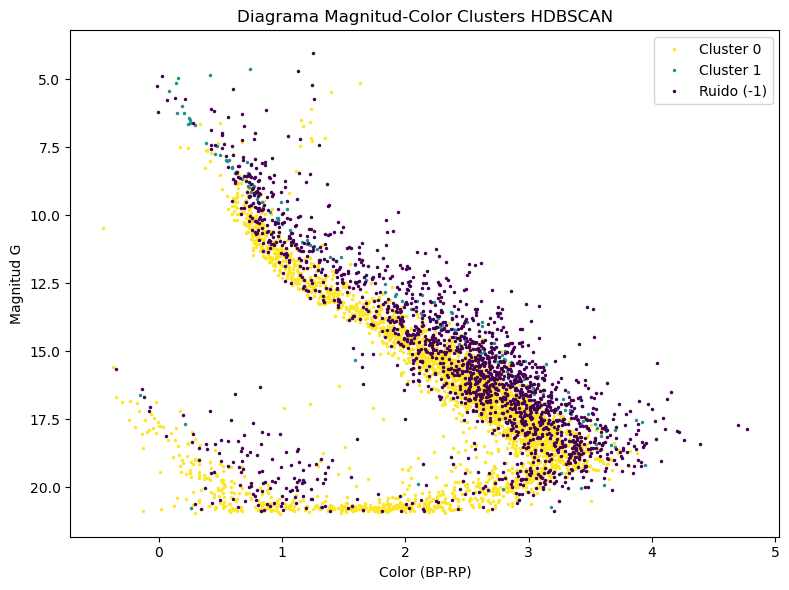

In [304]:
#Graficamos Diagrama Magnitud-Color con los clusters encontrados
plt.figure(figsize=(8,6))
for i, j in zip(list(unique_labels_coma), colors):
    condition = (coma['label_hb'] == i)
    legend_label = 'Ruido (-1)' if i == -1 else f'Cluster {i}'
    plt.plot(coma['bp_rp'][condition], coma['phot_g_mean_mag'][condition], 
     markerfacecolor = tuple(j), markeredgewidth=0, marker = 'o', linestyle='None',markersize = 2.5, alpha = 1,
     label=legend_label)
plt.xlabel("Color (BP-RP)")
plt.ylabel("Magnitud G")
plt.title('Diagrama Magnitud-Color Clusters HDBSCAN')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show() 

Número de estrellas en el cluster encontrado por ML:  155


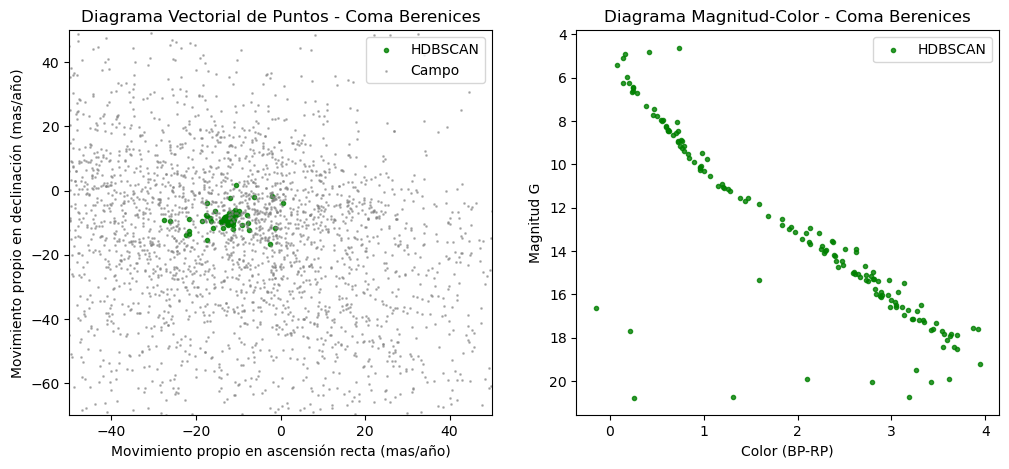

In [305]:
#Identificamos al Cluster 1 como Coma Berenices 
cluster_ML=coma[coma['label_hb'] == 1]
#Graficamos Diagrama Vecorial de puntos y Diagrama Magnitud-Color
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
campo_coma = coma[~coma.index.isin(cluster_ML.index)]
plt.scatter(cluster_ML['pmra'], cluster_ML['pmdec'], c='g', s=9, alpha=0.8, label='HDBSCAN')
plt.scatter(campo_coma['pmra'], campo_coma['pmdec'], c='gray', s=1, alpha=0.5, label='Campo')
plt.ylim(-70, 50)
plt.xlim(-50, 50)
plt.title('Diagrama Vectorial de Puntos - Coma Berenices')
plt.xlabel('Movimiento propio en ascensión recta (mas/año)')
plt.ylabel('Movimiento propio en declinación (mas/año)')
plt.legend()
plt.subplot(1,2,2)
plt.scatter(cluster_ML['bp_rp'], cluster_ML['phot_g_mean_mag'], c='g', s=9, alpha=0.8, label='HDBSCAN')
plt.xlabel('Color (BP-RP)')
plt.ylabel('Magnitud G')
plt.gca().invert_yaxis()
plt.title('Diagrama Magnitud-Color - Coma Berenices')
plt.legend()
plt.savefig('Coma_Berenices_HDBSCAN.png', dpi=300)
print("Número de estrellas en el cluster encontrado por ML: ", len(cluster_ML))
